<a href="https://colab.research.google.com/github/johnisaiah09/FinanceResearch-TCS-/blob/main/Stock_Market_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Imports and loading dataset
import pandas as pd
import matplotlib.pyplot as plt

data_raw = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")
data = data_raw.copy()

Shape: (6290, 8)
Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker'],
      dtype='object')
Data types: Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Ticker               object
dtype: object
Date range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00
Companies: ['AAPL' 'AMZN' 'GOOGL' 'MSFT' 'TSLA']
Rows per company: Ticker
AAPL     1258
AMZN     1258
GOOGL    1258
MSFT     1258
TSLA     1258
Name: count, dtype: int64
Number of invalid rows: 0


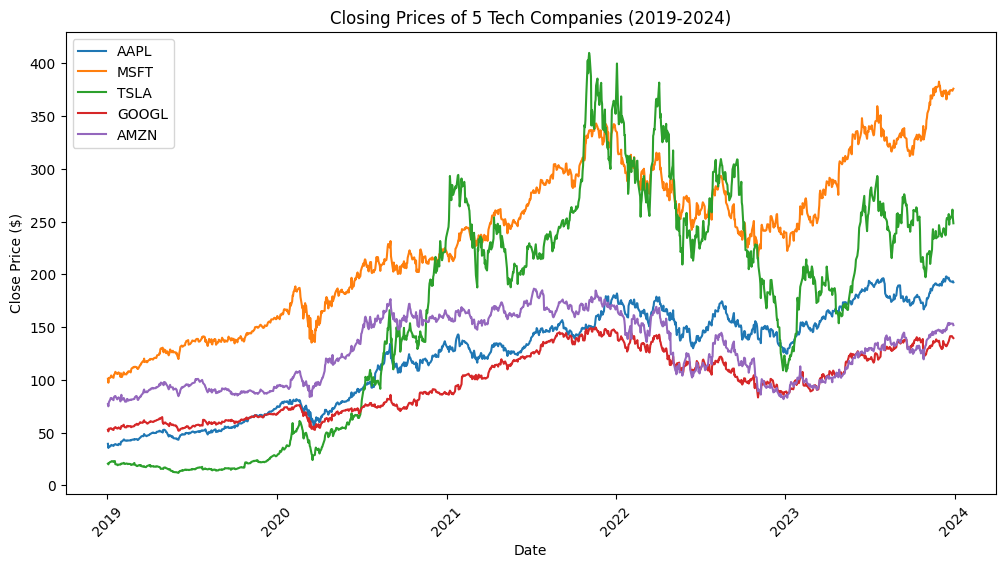

In [7]:
#EDA
print("Shape:", data.shape)
print("Columns:", data.columns)
print("Data types:", data.dtypes)
print("Date range:", data["Date"].min(), "to", data["Date"].max())
print("Companies:", data["Ticker"].unique())
print("Rows per company:", data["Ticker"].value_counts())

# Converting the Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Checking data is sorted
data = data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)
data.head(10)

# Checking for invalid OHLC rows

invalid_rows = data[
    (data["High"] < data["Open"]) |
    (data["High"] < data["Close"]) |
    (data["High"] < data["Low"]) |
    (data["Low"] > data["Open"]) |
    (data["Low"] > data["Close"])
]

print(f"Number of invalid rows: {len(invalid_rows)}")

# Understanding numerical data
data.describe()

# Summary stats by Company
summary = data.groupby("Ticker").agg(
    {
        "Close": ["mean","std","min","max"],
        "Volume": ["mean","std","min","max"]
    }
)
summary

# Closing Price Visualization
companies = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

plt.figure(figsize=(12,6))
for company in companies:
  stock = data[data["Ticker"] == company]
  plt.plot(stock["Date"], stock["Close"], label=company)

plt.title("Closing Prices of 5 Tech Companies (2019-2024)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.xticks(rotation=45)
plt.show()



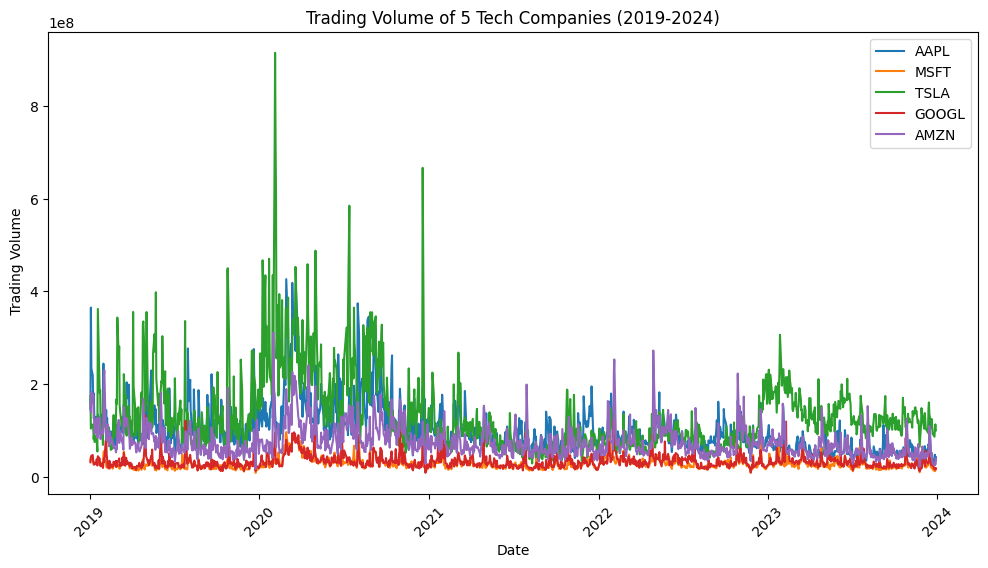

In [6]:
# Trading Volume Visualization

plt.figure(figsize=(12,6))
for company in companies:
  stock = data[data["Ticker"] == company]
  plt.plot(stock["Date"], stock["Volume"], label=company)

plt.title("Trading Volume of 5 Tech Companies (2019-2024)")
plt.xlabel("Date")
plt.ylabel(" Trading Volume")
plt.legend()
plt.xticks(rotation=45)
plt.show()